# Figure4: plotting and resource-data code

This notebook contains the original figure-production cells. Inputs are under `data/Figure4/`; outputs may be written to `output/`.

## Resource-data sheets included for this figure

- `fig4-cc-non_cx3cr1_with_cx3cr1_tcr-rna_tcr` — resource-data sheet for the corresponding panel.
- `fig4-cyto_exhau_score-cell_state` — resource-data sheet for the corresponding panel.
- `fig4-diversity-cd8_cx3cr1-min10` — resource-data sheet for the corresponding panel.
- `fig4-expand_in_subtype-delta_delta-stat` — resource-data sheet for the corresponding panel.
- `fig4-expand_in_subtype-post_pre_delta` — resource-data sheet for the corresponding panel.
- `fig4-expand_pct-cd8_cx3cr1-min10` — resource-data sheet for the corresponding panel.
- `fig4-pbulk_exprs-cx3cl1_in_TME` — resource-data sheet for the corresponding panel.
- `fig4-shannon-delta_delta-stat` — resource-data sheet for the corresponding panel.
- `fig4-shannon-post_pre_delta` — resource-data sheet for the corresponding panel.
- `fig4-tcr_share_inter_subtype-clone_frac_new` — resource-data sheet for the corresponding panel.
- `fig4a-tcr_share-post_novel-vs-pre_exist-clone_frac_new` — resource-data sheet for the corresponding panel.
- `fig4b-tcr_share-post_in_pre` — resource-data sheet for the corresponding panel.
- `fig4b-tcr_share-pre_in_post` — resource-data sheet for the corresponding panel.
- `fig4d-clone_change_type-clone_frac_pre_vs_post-by_state` — resource-data sheet for the corresponding panel.
- `fig4e-clone_change_type-clone_pct-by_state` — resource-data sheet for the corresponding panel.
- `fig4h-cell_pct_in_cyto_expand` — resource-data sheet for the corresponding panel.
- `fig4h-cell_pct_in_exhau_contract` — resource-data sheet for the corresponding panel.
- `fig4h-cyto_expand_cross_exhau_cluster-cell_pct-10` — resource-data sheet for the corresponding panel.
- `fig4h-cyto_expand_cross_exhau_cluster-cell_pct-20` — resource-data sheet for the corresponding panel.
- `fig4h-cyto_expand_cross_exhau_cluster-cell_pct-50` — resource-data sheet for the corresponding panel.
- `fig4h-exhau_contract_cross_exhau_cluster-cell_pct-10` — resource-data sheet for the corresponding panel.
- `fig4h-exhau_contract_cross_exhau_cluster-cell_pct-20` — resource-data sheet for the corresponding panel.
- `fig4h-exhau_contract_cross_exhau_cluster-cell_pct-50` — resource-data sheet for the corresponding panel.

The final resource tables use `NR` as the non-responder label. The original analysis cells are retained so that their complete plotting logic is traceable.

In [31]:
# Harmonize standalone response labels at input time: PR -> NR.
harmonize_nr_labels <- function(x) {
  normalize_df <- function(df) {
    for (nm in names(df)) {
      if (is.character(df[[nm]]) || is.factor(df[[nm]])) {
        df[[nm]] <- gsub("\bPR\b", "NR", as.character(df[[nm]]), perl = TRUE)
      }
    }
    df
  }
  if (is.data.frame(x)) return(normalize_df(x))
  if (isS4(x) && "meta.data" %in% slotNames(x)) {
    x@meta.data <- normalize_df(x@meta.data)
  }
  x
}


# Figure 4 plotting code\n\nOrganized copy of the manuscript plotting notebook. This standalone notebook runs from `code/`; inputs are in `../data/` and outputs are written to `../output/`. Large inputs are relative symbolic links, described in `../../data/DATA_INPUT_MANIFEST.tsv`.\n

# figure 4 vlz

- kernel: r_env, R 4.1.3
- date: 2023-12-28

## load

In [32]:
library(tidyverse)
if (requireNamespace("logging", quietly = TRUE)) { library(logging); logging::basicConfig() } else { loginfo <- function(...) invisible(NULL) }
library(ggpubr)
library(ggsci)
library(patchwork)
library(Seurat)

source('shared/r_funcs.r')

theme_set(theme_pubr())

options(warn = -1)

outdir <- "../output"
create_dir(outdir)

In [33]:
f_pat_gp <- '../data/Figure4/tables/patient_info_v2.tsv'
gp <- 'response'
gp_lvls$response <- c('R', 'NR')
gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_comp_diff_map$response <- list(c('R', 'NR'))
gp_comp_map_pre$response <- list(c('R-pre', 'NR-pre'))
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

In [34]:
celltype_map <- list(
    'T_MKI67' = c('T_Prolif')
)

cell_state_map <- list(
    'cytotoxic' = c('CD8_ANXA1', 'CD8_CCL5', 'CD8_CX3CR1', 'CD8_FOS', 'CD8_GZMK', 'CD8_KLRB1'),
    'exhausted' = c('CD4_CXCL13', 'CD8_CXCL13', 'CD8_TYMS', 'T_MKI67', 'Treg_TNFRSF4'),
    'dying' = c('T_Mito'),
    'others' = c('CD4_KLRB1', 'CD8_CD74', 'CD8_IFIT1', 'T_IL7R', 'T_Ribo', 'Treg_LTB')
)
cell_state_order <- c('cytotoxic', 'exhausted', 'dying', 'others')
cell_state_color <- c('exhausted' = '#023fa5', 'cytotoxic' = 'red', 
                      'dying' = '#bb7784', 'others' = '#ff9639')

## pre-post TCR sharing: 4a-c

In [35]:
f_share <- '../data/Figure4/stage4/a05_clone_share/pre_post_share/pre_post_share-per_clone_subtype.tsv'  # subtype level share
f_clone_share_sample <- '../data/Figure4/stage4/a05_clone_share/pre_post_share/pre_post_share-by_sample-per_clone.tsv'  # sample level share

min_cell_per_sample_subtype <- 10  # to cosistent with expand percent analysis

### 4a: vln of clone fraction in Treat, novel vs pre-exisiting

- sharing at sample level
- clone fraction (based on RNA & TCR data) in mandarad_group, post-novel & pre-post-shared types
- min_cell_per_clone = 2

In [36]:
min_cell_per_clone <- 2
xorder <- c('R-pre_existing', 'R-post_novel', 'NR-pre_existing', 'NR-post_novel')
comp_ls <- list(
    c('R-pre_existing', 'R-post_novel'), c('NR-pre_existing', 'NR-post_novel'),
    c('R-pre_existing', 'NR-pre_existing'), c('R-post_novel', 'NR-post_novel')
)

clone_share_info <- read_tsv(f_clone_share_sample, show_col_types = F)
clone_share_info %>% dim

[1] 67283    17

In [37]:
# stat
df_stat <- clone_share_info %>% 
    filter(!is.na(sample_post)) %>%  # all Treat clones %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(xlab = case_when(
        share_type == 'pre_post_share' ~ paste0(.data[[gp]], '-pre_existing'), 
        share_type == 'post_specific' ~ paste0(.data[[gp]], '-post_novel'), 
        TRUE ~ 'others'
    )) %>%
    filter(n_cell_per_sample_clone_post >= min_cell_per_clone)  # filter clones with few cells
df_stat %>% dim
df_stat %>% write_tsv(str_glue('{outdir}/fig4a-tcr_share-post_novel-vs-pre_exist-clone_frac_new.tsv'))

[1] 4689   19

# A tibble: 4 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W    p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>    <dbl>
1 R-pre… R-pos…                1 FALSE    861  1192      NA     665255  1.62e-30
2 NR-pr… NR-po…                2 FALSE   1377  1259      NA    1084928. 5.07e-29
3 R-pre… NR-pr…                3 FALSE    861  1377      NA     760869  1.30e-29
4 R-pos… NR-po…                4 FALSE   1192  1259      NA     996450  6.98e-45
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


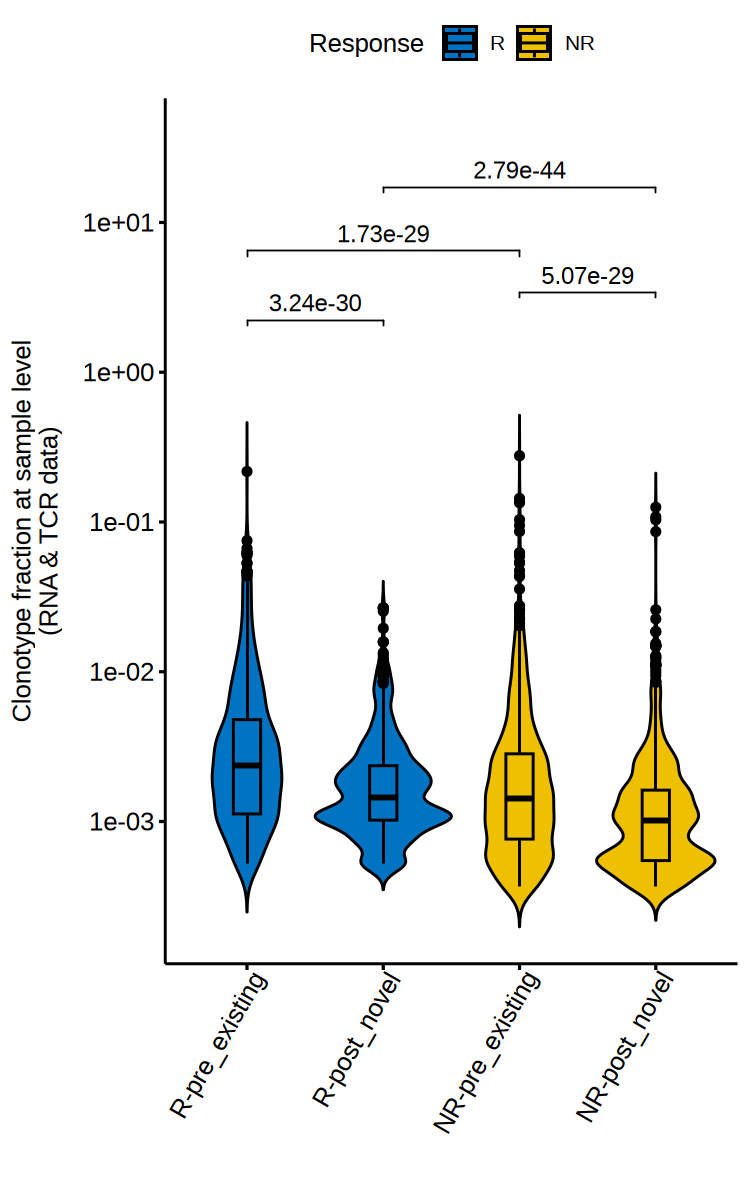

In [38]:
# Plot
plot_data_4a <- read_tsv(
    str_glue('{outdir}/fig4a-tcr_share-post_novel-vs-pre_exist-clone_frac_new.tsv'),
    show_col_types = FALSE
) %>%
    mutate(pat_gp = factor(.data[[gp]], gp_lvls[[gp]]))

p <- ggviolin(
    plot_data_4a,
    x = 'xlab',
    y = 'clone_frac_new_post',
    fill = 'pat_gp',
    add = 'boxplot',
    palette = 'jco',
    order = xorder
) +
    scale_y_continuous(
        trans = 'log10',
        expand = expansion(mult = c(0.05, 0.12))
    ) +
    labs(
        x = '',
        y = 'Clonotype fraction at sample level\n(RNA & TCR data)',
        fill = 'Response'
    ) +
    theme(axis.text.x = element_text(angle = 60, hjust = 0.96))

# On a log axis, use multiplicative spacing so the four brackets do not overlap.
panel_stats <- panel_wilcox_stats(
    data = p$data,
    x = 'xlab',
    y = 'clone_frac_new_post',
    comparisons = comp_ls,
    apply_correction = TRUE,
    correction_method = 'BH'
) %>%
    arrange(comparison_order)

y_max_4a <- max(plot_data_4a$clone_frac_new_post, na.rm = TRUE)
panel_stats$y.position <- y_max_4a * 10 ^ seq(
    from = 0.10,
    to = 0.65,
    length.out = nrow(panel_stats)
)

p <- add_panel_wilcox(p, panel_stats)
attr(p, 'panel_wilcox_stats') <- panel_stats
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue('{outdir}/fig4a-vln_tcr_share-post_novel-vs-pre_exist-clone_frac_new.pdf'),
    plot = p,
    width = 5,
    height = 7
)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 5, repr.plot.height = 8, repr.plot.res = 150)
p


### 4b-1: all Baseline vs all Treat in Baseline

- all Baseline, all Treat overlap TCRs / all Baseline TCRs, cell type level
- min_cell_per_sample_subtype = 10

In [39]:
df <- read_tsv(f_share, show_col_types = F)

# rename cell type
for (nm in names(celltype_map)) {
    df$subtype[df$subtype %in% celltype_map[[nm]]] <- nm
}

In [40]:
# stat
df_stat <- df %>% 
    filter(!is.na(sample_pre)) %>%  # all Baseline TCRs
    add_count(sample_pre, subtype, name = 'n_clone_per_samp_subtype') %>%
    count(patient, subtype, share_type, n_clone_per_samp_subtype, n_cell_per_sample_subtype_pre, name = 'n_clone') %>% 
    pivot_wider(names_from = 'share_type', values_from = 'n_clone', values_fill = 0) %>%
    filter(n_cell_per_sample_subtype_pre >= min_cell_per_sample_subtype) %>%
    mutate(pct = 100 * pre_post_share / n_clone_per_samp_subtype) %>%
    filter(!grepl('^NK', subtype)) %>%  # no NK cells
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
df_stat %>% write_tsv(str_glue('{outdir}/fig4b-tcr_share-pre_in_post.tsv'))
loginfo('%g recores', nrow(df_stat))

2026-07-17 22:48:59.096344 INFO::513 recores


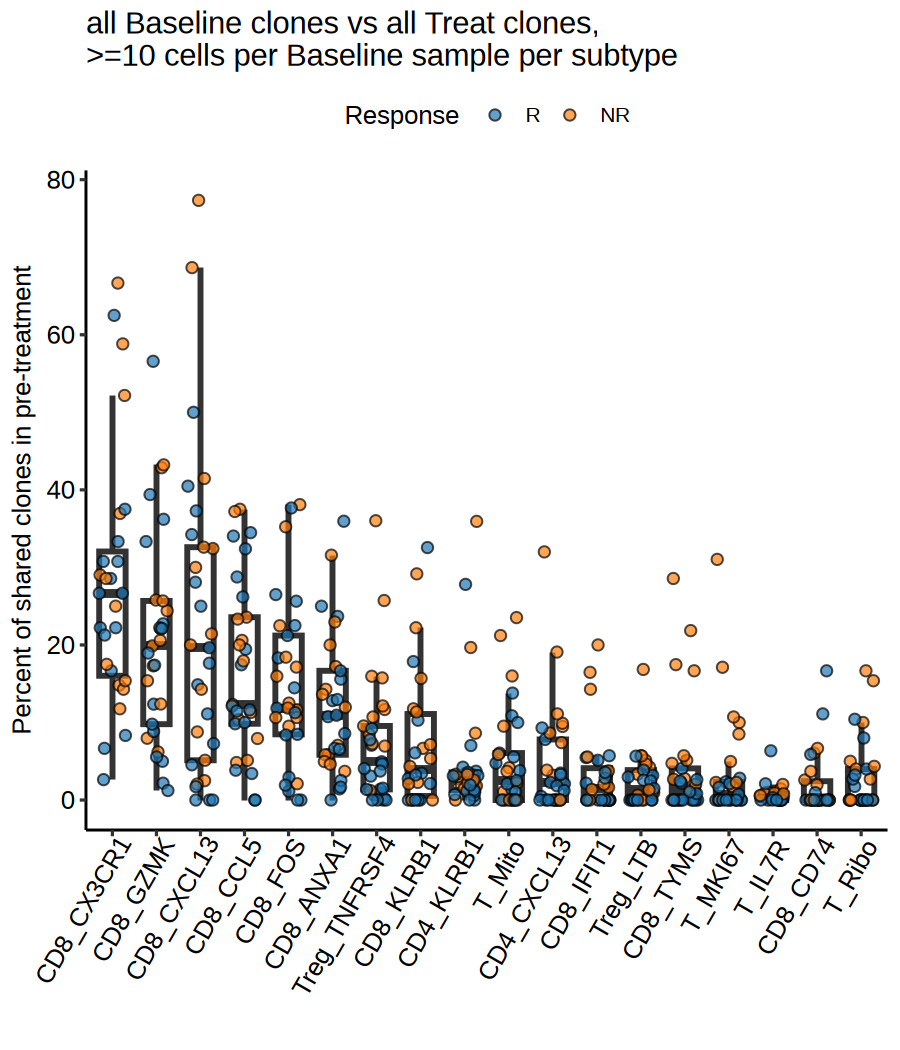

In [41]:
# plot
dp <- read_tsv(str_glue('{outdir}/fig4b-tcr_share-pre_in_post.tsv'), show_col_types = F)
xorder <- dp %>%
        summarise(.by = c('subtype'), val = median(pct)) %>%
        arrange(-val) %>%
        pull('subtype')
p <- dp %>%
    cell_comp_boxplot(x = 'subtype', xorder = xorder, y = 'pct', pair_by = NULL, seed_i = 12345, size = 2,
                      pt_fill = gp, fill_order = gp_lvls[[gp]], xangle = 60, facet_by = NULL,
                      ytitle = 'Percent of shared clones in pre-treatment') +
    labs(title = str_glue('all Baseline clones vs all Treat clones,',
                          '\n>={min_cell_per_sample_subtype} cells per Baseline sample per subtype'),
         fill = 'Response') 
ggsave(filename = str_glue('{outdir}/fig4b-box_tcr_share-pre_in_post-min{min_cell_per_sample_subtype}.pdf'),
       plot = p, width = 6, height = 6)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 6, repr.plot.height = 7, repr.plot.res = 150)
p


### 4b-2: all Baseline vs all Treat in Treat

- all Baseline, all Treat overlap TCRs / all Treat TCRs, cell type level
- min_cell_per_sample_subtype = 10

In [42]:
df <- read_tsv(f_share, show_col_types = F)
# rename cell type
for (nm in names(celltype_map)) {
    df$subtype[df$subtype %in% celltype_map[[nm]]] <- nm
}
# stat
df_stat <- df %>% 
    filter(!is.na(sample_post)) %>%  # all Treat TCRs
    add_count(sample_post, subtype, name = 'n_clone_per_samp_subtype') %>%
    count(patient, subtype, share_type, n_clone_per_samp_subtype, n_cell_per_sample_subtype_post, name = 'n_clone') %>% 
    pivot_wider(names_from = 'share_type', values_from = 'n_clone', values_fill = 0) %>% 
    filter(n_cell_per_sample_subtype_post >= min_cell_per_sample_subtype) %>%
    mutate(pct = 100 * pre_post_share / n_clone_per_samp_subtype) %>%
    filter(!grepl('^NK', subtype)) %>%  # no NK cells
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
df_stat %>% write_tsv(str_glue('{outdir}/fig4b-tcr_share-post_in_pre.tsv'))
loginfo('%g records', nrow(df_stat))

2026-07-17 22:49:01.467689 INFO::415 records


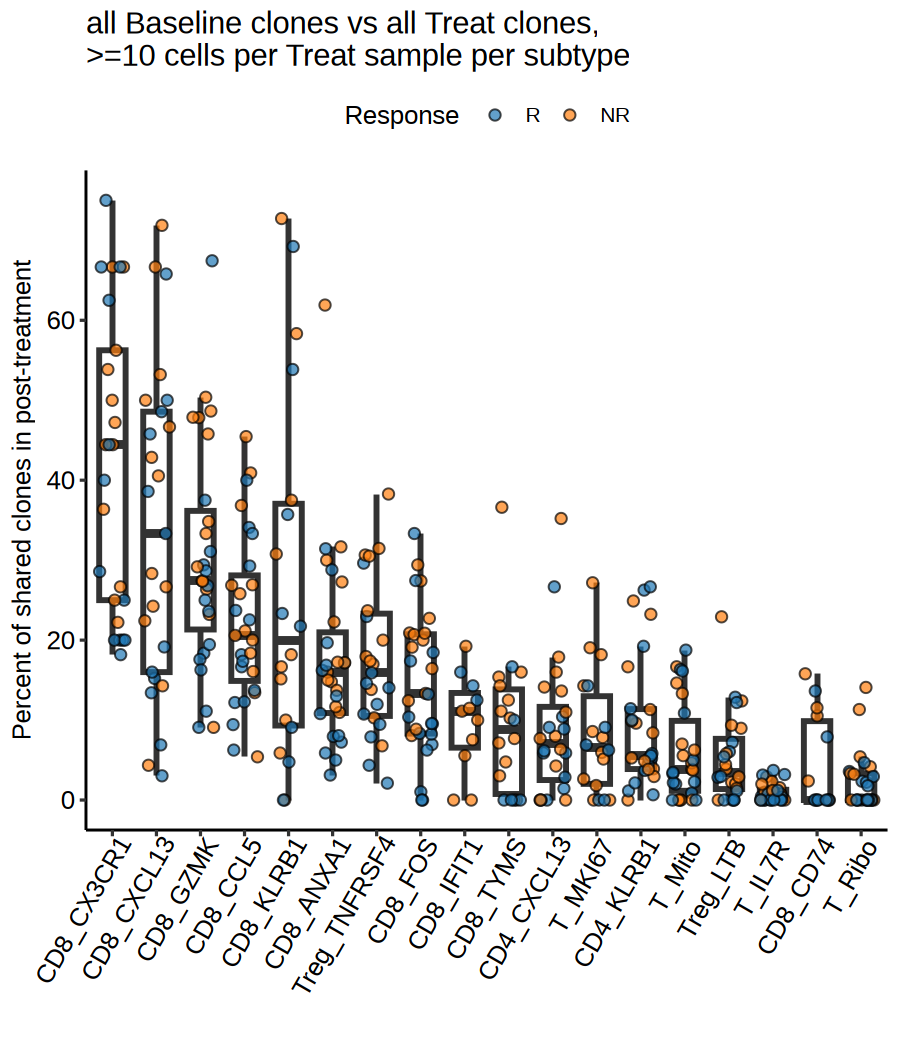

In [43]:
# plot
dp <- read_tsv(str_glue('{outdir}/fig4b-tcr_share-post_in_pre.tsv'), show_col_types = F)
xorder <- dp %>%
        summarise(.by = c('subtype'), val = median(pct)) %>%
        arrange(-val) %>%
        pull('subtype')
p <- dp %>%
    cell_comp_boxplot(x = 'subtype', xorder = xorder, y = 'pct', pair_by = NULL, seed_i = 12345, size = 2,
                      pt_fill = gp, fill_order = gp_lvls[[gp]], xangle = 60, facet_by = NULL,
                      ytitle = 'Percent of shared clones in post-treatment') +
    labs(title = str_glue('all Baseline clones vs all Treat clones,',
                          '\n>={min_cell_per_sample_subtype} cells per Treat sample per subtype'),
         fill = 'Response') 
ggsave(filename = str_glue('{outdir}/fig4b-box_tcr_share-post_in_pre-min{min_cell_per_sample_subtype}.pdf'),
       plot = p, width = 6, height = 6)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 6, repr.plot.height = 7, repr.plot.res = 150)
p


### 4c: share clone percent in post

In [44]:
f_pct_info <- '../data/Figure4/figures/fig4/fig4b-tcr_share-post_in_pre.tsv'
used_ctypes <- c(
    'CD8_FOS', 'CD8_GZMK', 'CD8_CXCL13', 
    'CD8_ANXA1', 'Treg_TNFRSF4', 'CD8_TYMS'
)

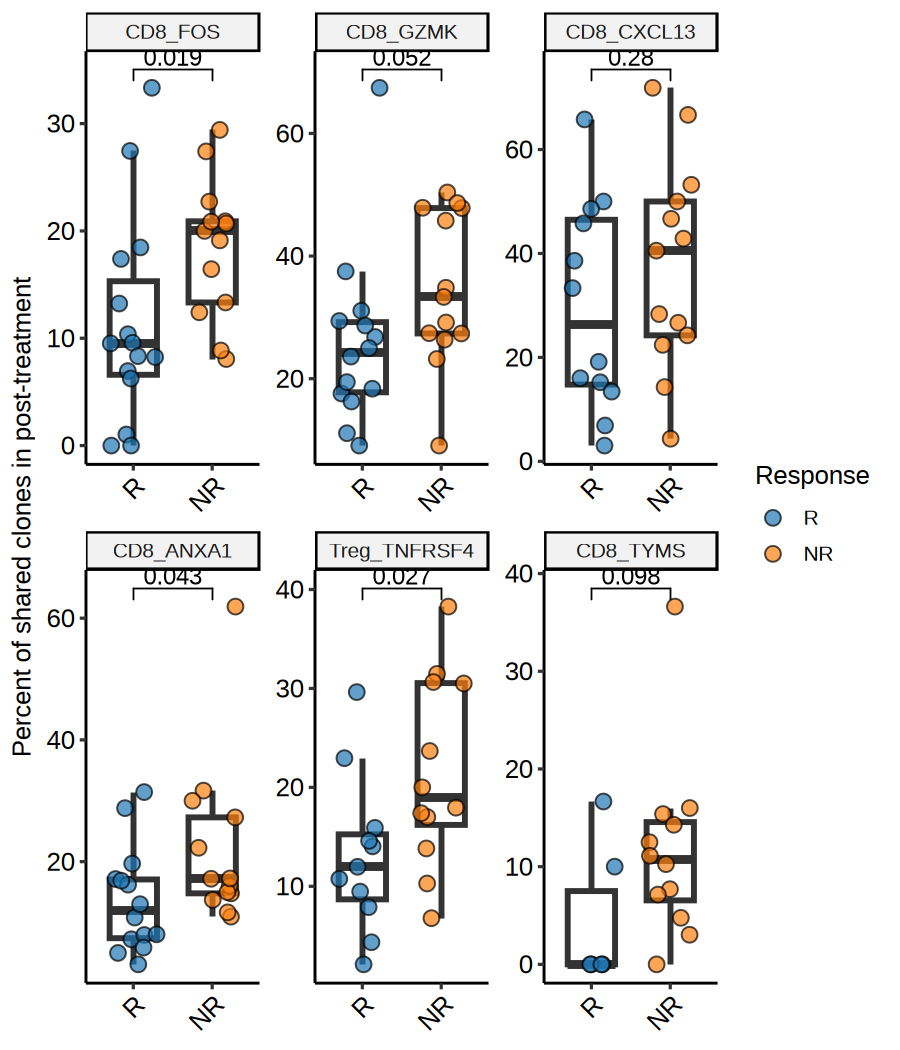

In [45]:
p <- read_tsv(f_pct_info, show_col_types = F) %>% 
    filter(subtype %in% used_ctypes) %>%
    mutate(subtype = factor(subtype, used_ctypes)) %>%
    cell_comp_boxplot(x = gp, y = 'pct', pt_fill = gp, facet_by = 'subtype', pair_by = NULL,
                      xorder = gp_lvls[[gp]], fill_order = gp_lvls[[gp]], ncol = 3) +
    stat_compare_means(comparisons = gp_comp_diff_map[[gp]]) +
    labs(y = 'Percent of shared clones in post-treatment', fill = 'Response') +
    theme(axis.title.x = element_blank(), legend.position = 'right')
ggsave(filename = str_glue('{outdir}/fig4c-box_tcr_share-share_clone_pct_comp-by_{gp}.pdf'),
       plot = p, width = 7, height = 7)
options(repr.plot.width = 6, repr.plot.height = 7, repr.plot.res = 150)
p

## clone change type (pre vs post): 4d-h

In [46]:
# cell source of 4 clone cat
f_cell_source <- '../data/Figure4/stage4/a05_clone_share/pre_post_share/clone_frac_in_sample/clone_cell_source-cell_state-clone_change_type.tsv'
# clone sharing intra- cell state level (with sharing_type)
f_share_type <- '../data/Figure4/stage4/a05_clone_share/pre_post_share/pre_post_share-per_clone-cell_state.tsv'
# merged clone frac/clone change type (sample level) & clone sharing info (no sharing_type)
f_clone_change <- '../data/Figure4/stage4/a05_clone_share/pre_post_share/clone_frac_in_sample/clone_pair_patient-clone_change_type-chisq.tsv'

clone_type_lvl <- c('Expanded', 'Contracted', 'Persistent')
clone_type_color_map <- c(
    'Expanded' = '#EE0000FF', 'Contracted' = '#3B4992FF', 'Persistent' = 'gray60'
)
ctype_colors <- c(
    CD8_ANXA1 = '#8C0439', CD8_CCL5 = '#A12253', CD8_CX3CR1 = '#B6416D', CD8_FOS = '#CC6088',
    CD8_GZMK = '#E17FA2', CD8_KLRB1 = '#F79EBD', CD4_CXCL13 = '#003CA5', CD8_CXCL13 = '#2F5DB1', 
    CD8_TYMS = '#5E7FBD', T_MKI67 = '#8DA1C9', Treg_TNFRSF4 = '#BDC3D6', T_Mito = '#7B7D7B',
    CD4_KLRB1 = '#DF9608', CD8_CD74 = '#E2A22E', CD8_IFIT1 = '#E5AE54', T_IL7R = '#E8BA7A', 
    T_Ribo = '#EBC6A0', Treg_LTB = '#EFD3C6'
)

### 4d: scatter show clone type

- desc: only pre-post shared clones (clone sharing defined intra cell state)

In [47]:
xy_tick_labels <- c(0.001, 0.01, 0.1)
used_states <- c('cytotoxic', 'exhausted', 'dying', 'others')

In [48]:
df <- read_tsv(f_clone_change, show_col_types = F) %>%
    filter(!grepl('NK', cell_state)) %>%  # no NK cells
    filter(cell_state %in% used_states) %>%
    select(-c('mandard_group', 'response_degree', 'treatment_group')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
df <- read_tsv(f_share_type, show_col_types = F) %>% 
    filter(share_type == 'pre_post_share') %>%
    select(patient, patient_id, clonotype, cell_state, share_type) %>% 
    distinct() %>%
    merge(df, by = c('patient', 'patient_id', 'clonotype', 'cell_state'))
df %>% write_tsv(str_glue('{outdir}/figs7a-clone_change_type-clone_frac_pre_vs_post-by_state-only_share.tsv'))

loginfo('%g records', nrow(df))

2026-07-17 22:49:07.404562 INFO::4240 records


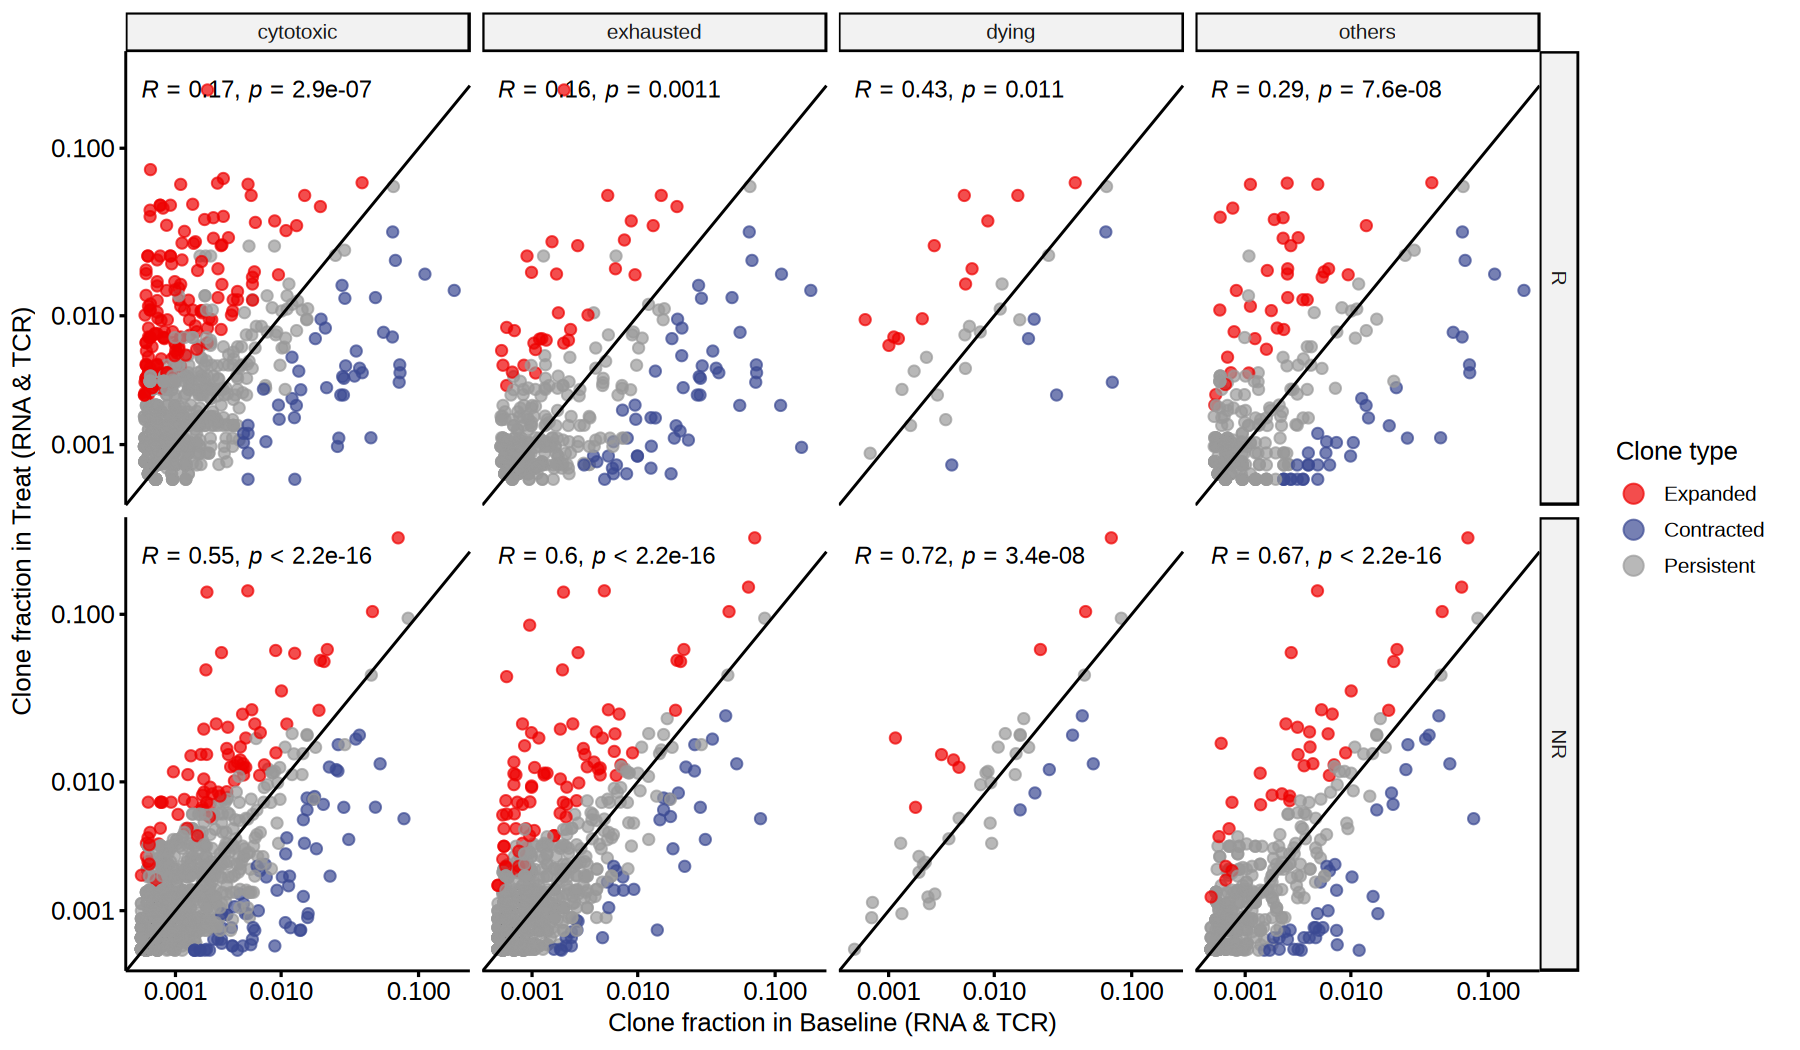

In [49]:
# scatter show expand type use clone fraction
p <- read_tsv(str_glue('{outdir}/figs7a-clone_change_type-clone_frac_pre_vs_post-by_state-only_share.tsv'), show_col_types = F) %>%
    mutate(clone_change_type = factor(clone_change_type, levels = clone_type_lvl),
           frow = factor(.data[[gp]], gp_lvls[[gp]]),
           fcol = factor(cell_state, used_states)) %>%
    ggscatter(x = 'clone_frac_in_sample_pre', y = 'clone_frac_in_sample_post', color = 'clone_change_type', alpha = 0.7, cor.coef = T) +
    geom_abline(slope = 1, intercept = 0) +
    facet_grid(frow ~ fcol)  +
    scale_x_continuous(breaks = xy_tick_labels) +
    scale_y_continuous(breaks = xy_tick_labels) +
    scale_color_manual(values = clone_type_color_map) +
    guides(color = guide_legend(override.aes = list(size = 4))) +
    coord_trans(x = lognp_trans(n = 0.001), y = lognp_trans(n = 0.001)) +
    labs(x = 'Clone fraction in Baseline (RNA & TCR)', y = 'Clone fraction in Treat (RNA & TCR)',
         color = 'Clone type') +
    theme(legend.position = 'right')
ggsave(filename = str_glue('{outdir}/figs7a-scatter-clone_chage_type-clone_frac_pre_vs_post-by_state-only_share.pdf'),
       plot = p, width = 15, height = 5)
# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 150)
p


### 4e: clone change type composition

- to prove cytotoxic clusters are pre low-expand to post high-expand, exhausted clusters are pre-high expand clones to post-low
- show contacted/expaned clone compositions at sample level

In [50]:
comp_ls <- list(
    c('R-Contracted', 'R-Expanded'), 
    c('NR-Contracted', 'NR-Expanded')
)
used_states <- c('cytotoxic', 'exhausted')

In [51]:
dp <- read_tsv(f_clone_change, show_col_types = F) %>% 
    filter(!grepl('NK', cell_state)) %>%  # no NK cells
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    add_count(patient, cell_state, name = 'n_clone_per_sample_state') %>% 
    count(patient, .data[[gp]], cell_state, clone_change_type, n_clone_per_sample_state) %>% 
    mutate(pct = 100 * n / n_clone_per_sample_state) %>%
    pivot_wider(id_cols = c('patient', gp, 'cell_state'),
                names_from = 'clone_change_type', 
                values_from = 'pct', values_fill = 0) %>%
    pivot_longer(cols = clone_type_lvl, names_to = 'clone_change_type', values_to = 'pct') %>%
    mutate(cell_state = factor(cell_state, levels = cell_state_order))
dp %>% write_tsv(str_glue('{outdir}/fig4e-clone_change_type-clone_pct-by_state.tsv'))
loginfo('%g records, %g clone type', nrow(dp), length(unique(dp$clone_change_type)))

2026-07-17 22:49:09.738743 INFO::348 records, 3 clone type


# A tibble: 4 × 14
  cell_state group1        group2    comparison_order paired    n1    n2 n_pairs
  <chr>      <chr>         <chr>                <int> <lgl>  <int> <int>   <int>
1 cytotoxic  R-Contracted  R-Expand…                1 FALSE     16    16      NA
2 cytotoxic  NR-Contracted NR-Expan…                2 FALSE     13    13      NA
3 exhausted  R-Contracted  R-Expand…                1 FALSE     16    16      NA
4 exhausted  NR-Contracted NR-Expan…                2 FALSE     13    13      NA
# ℹ 6 more variables: statistic_W <dbl>, p_raw <dbl>, p_adj <dbl>,
#   p_display <dbl>, label <chr>, y.position <dbl>


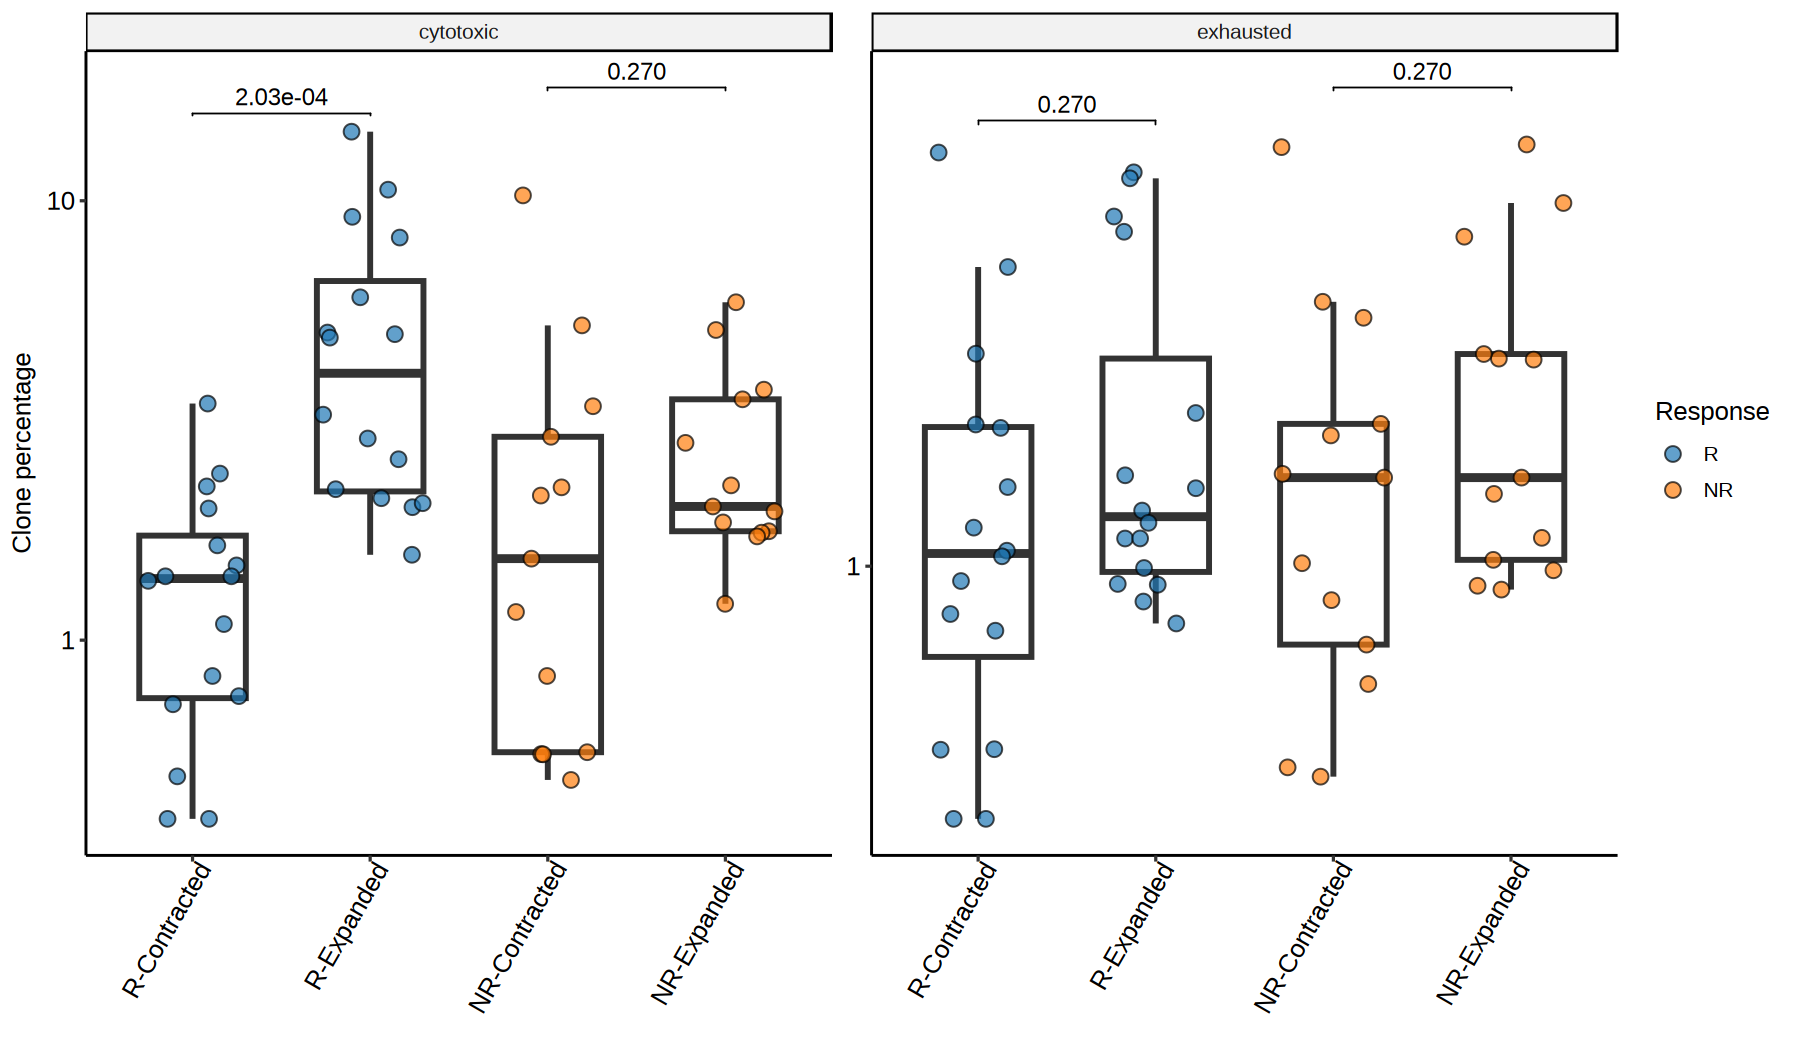

In [52]:

# boxplot show good vs poor clone change type proportion at sample level
p <- read_tsv(str_glue('{outdir}/fig4e-clone_change_type-clone_pct-by_state.tsv'), show_col_types = F) %>%
    filter(clone_change_type %in% c('Expanded', 'Contracted'),
           cell_state %in% used_states) %>%
    cell_comp_boxplot(x = c(gp, 'clone_change_type'),  y = 'pct', pt_fill = gp, facet_by = 'cell_state', 
                      pair_by = NULL, xorder = unlist(comp_ls), fill_order = gp_lvls[[gp]], xangle = 60) + 
    scale_y_continuous(breaks = c(1, 10, 100))  +
    coord_trans(y = 'lognp') + 
    labs(fill = 'Response', y = 'Clone percentage') +
    theme(legend.position = 'right', axis.title.x = element_blank())
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'pct',
    comparisons = comp_ls,
    facet_by = 'cell_state',
    use_paired = FALSE,
    pair_by = 'patient',
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig4e-box-clone_change_type-clone_pct-by_state.pdf'),
       plot = p, width = 6, height = 5.5)
# 在当前 notebook 中显示最后生成的图。
p


### 4f: subtype source of interested clones

only consider pre-post paired samples; consider:
- cytotoxic-Expanded, exhausted-Contracted clones
- Contracted clones in cytotoxic clusters, Expanded clones in exhausted clusters

In [53]:
used_cat <- c(
  'Contracted clones in exhausted clusters', 'Expanded clones in exhausted clusters',
  'Contracted clones in cytotoxic clusters', 'Expanded clones in cytotoxic clusters'
)

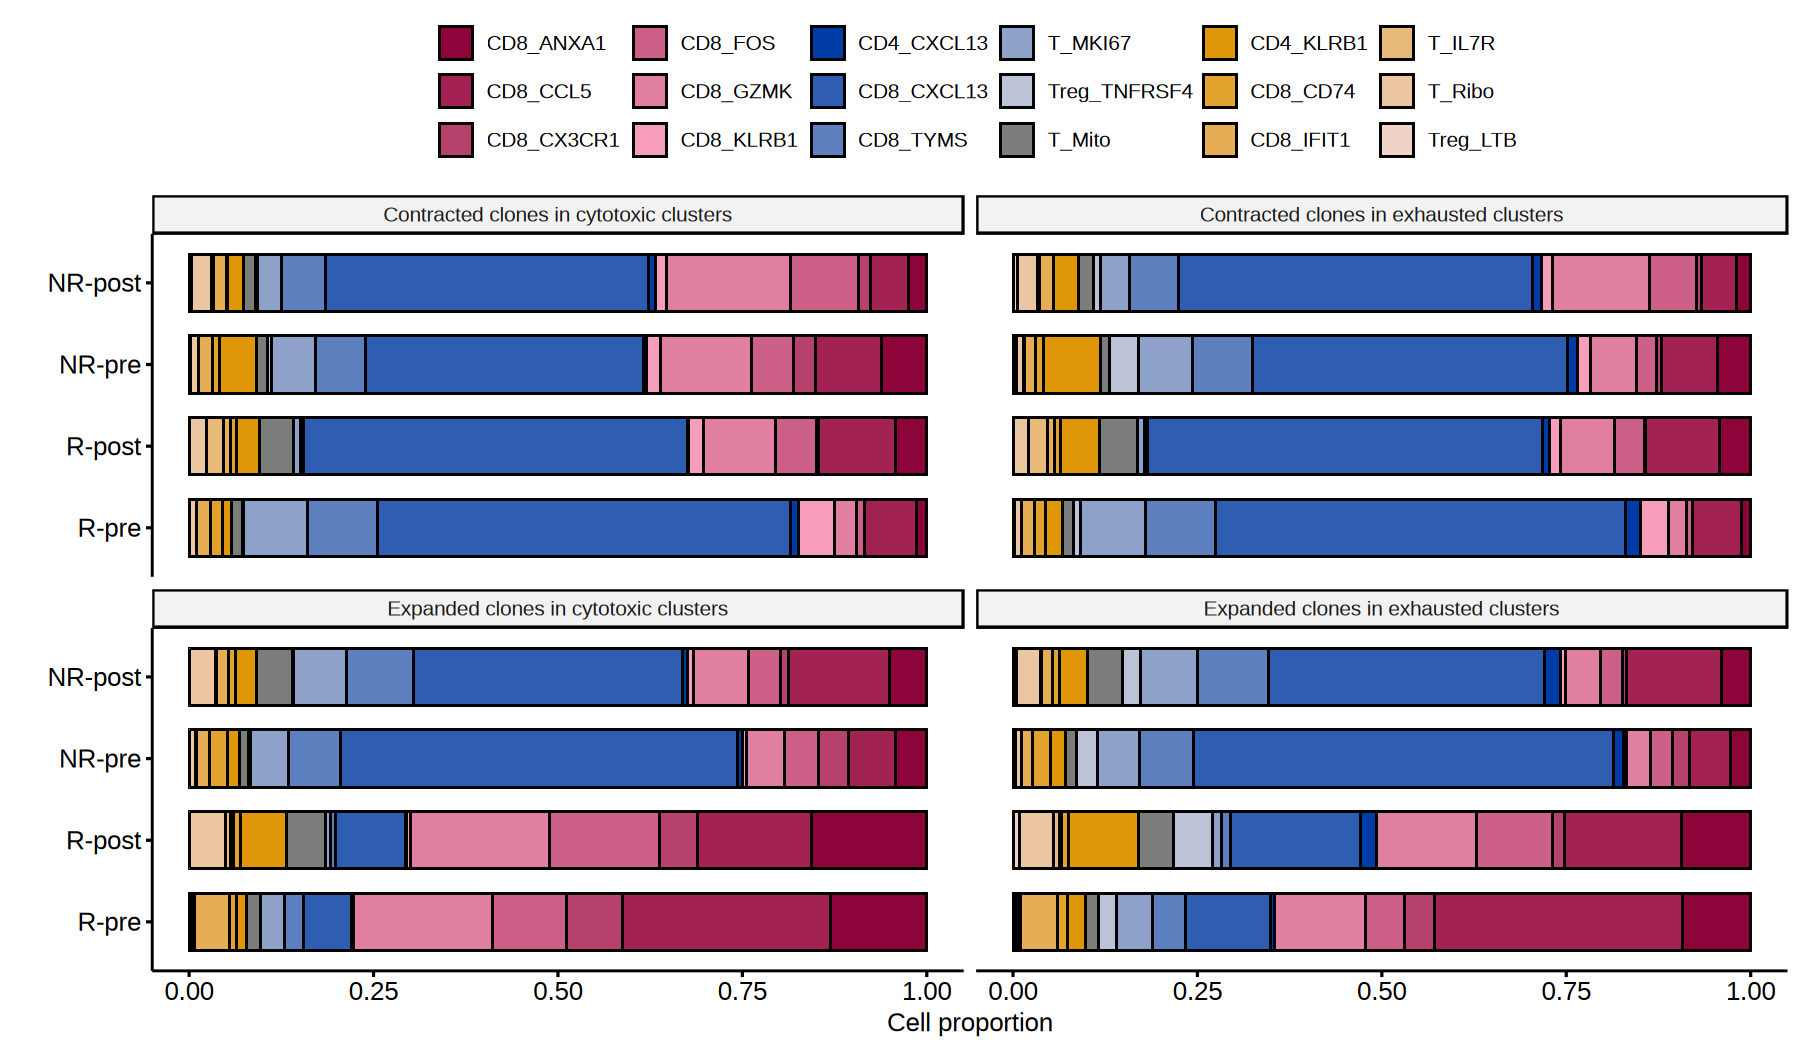

In [54]:
# 生成 Fig. 4f 最终作图数据
dp_4f <- read_tsv(
    f_cell_source,
    show_col_types = FALSE
) %>%
    filter(!grepl('NK', celltype)) %>%
    filter(clone_cat %in% used_cat) %>%
    count(
        .data[[gp]],
        sample_type,
        clone_cat,
        celltype,
        name = 'n_cell'
    ) %>%
    group_by(
        .data[[gp]],
        sample_type,
        clone_cat
    ) %>%
    mutate(
        n_cell_total = sum(n_cell),
        cell_proportion = n_cell / n_cell_total
    ) %>%
    ungroup() %>%
    mutate(
        response_stype = factor(
            paste0(.data[[gp]], '-', sample_type),
            levels = comb_order
        ),
        celltype = factor(
            celltype,
            levels = names(ctype_colors)
        )
    ) %>%
    arrange(
        clone_cat,
        response_stype,
        celltype
    )

# 输出运行时 Source Data
write_tsv(
    dp_4f,
    str_glue(
        '{outdir}/fig4f-cell_source-cytoExpand_exhauContract.tsv'
    )
)

# 使用同一份数据作图
p <- dp_4f %>%
    ggbarplot(
        x = 'n_cell',
        y = 'response_stype',
        fill = 'celltype',
        position = position_fill()
    ) +
    facet_wrap(~ clone_cat) +
    scale_fill_manual(values = ctype_colors) +
    guides(
        fill = guide_legend(nrow = 3)
    ) +
    labs(
        x = 'Cell proportion',
        y = '',
        fill = ''
    )

ggsave(
    filename = str_glue(
        '{outdir}/fig4f-bar-cell_source-cytoExpand_exhauContract.pdf'
    ),
    plot = p,
    width = 12,
    height = 7
)

p

## cell percent of specific cluster in specific clone cat

- date: 2024-02-29
- desc: cell level

In [55]:
min_cell <- 10
clone_source <- read_tsv(f_cell_source, show_col_types = F) %>% 
    filter(!grepl('NK', celltype)) 
loginfo('total %g cells, %g samples', nrow(clone_source), length(unique(clone_source$sample)))

2026-07-17 22:49:13.746464 INFO::total 66214 cells, 58 samples


### 4g: exhausted clusters in exhausted contracted

In [56]:
prefix <- 'fig4g-cell_pct_in_exhau_contract'
used_ctypes <- c('CD8_TYMS', 'T_MKI67')
df <- clone_source %>% 
    filter(clone_cat == 'Contracted clones in exhausted clusters') %>% 
    mutate(cellgp = if_else(celltype %in% used_ctypes, celltype, 'others')) %>% 
    count(patient, sample_type, cellgp, name = 'n_cell') %>% 
    pivot_wider(id_cols = c('patient', 'sample_type'), names_from = 'cellgp',
                values_from = 'n_cell', values_fill = 0) %>% 
    pivot_longer(cols = -c('patient', 'sample_type'), names_to = 'cellgp', values_to = 'n_cell') %>% 
    add_count(patient, sample_type, name = 'n_cell_per_sample', wt = n_cell) %>% 
    mutate(pct = 100 * n_cell / n_cell_per_sample) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
loginfo('%g records', nrow(df))
df %>% write_tsv(str_glue('{outdir}/{prefix}.tsv'))

2026-07-17 22:49:14.633903 INFO::147 records


# A tibble: 4 × 13
  group1 group2  comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>              <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  R-post                 1 FALSE     14    10      NA         138 4.91e-5
2 NR-pre NR-post                2 FALSE     13     8      NA          61 5.38e-1
3 R-pre  NR-pre                 3 FALSE     14    13      NA         117 2.20e-1
4 R-post NR-post                4 FALSE     10     8      NA          12 5.45e-3
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>
# A tibble: 4 × 13
  group1 group2  comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>              <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  R-post                 1 FALSE     14    10      NA         136 1.03e-4
2 NR-pre NR-post                2 FALSE     13     8      NA          68 2.60e-1
3 R-pre  NR-pre                 3 FALSE     14    13      NA      

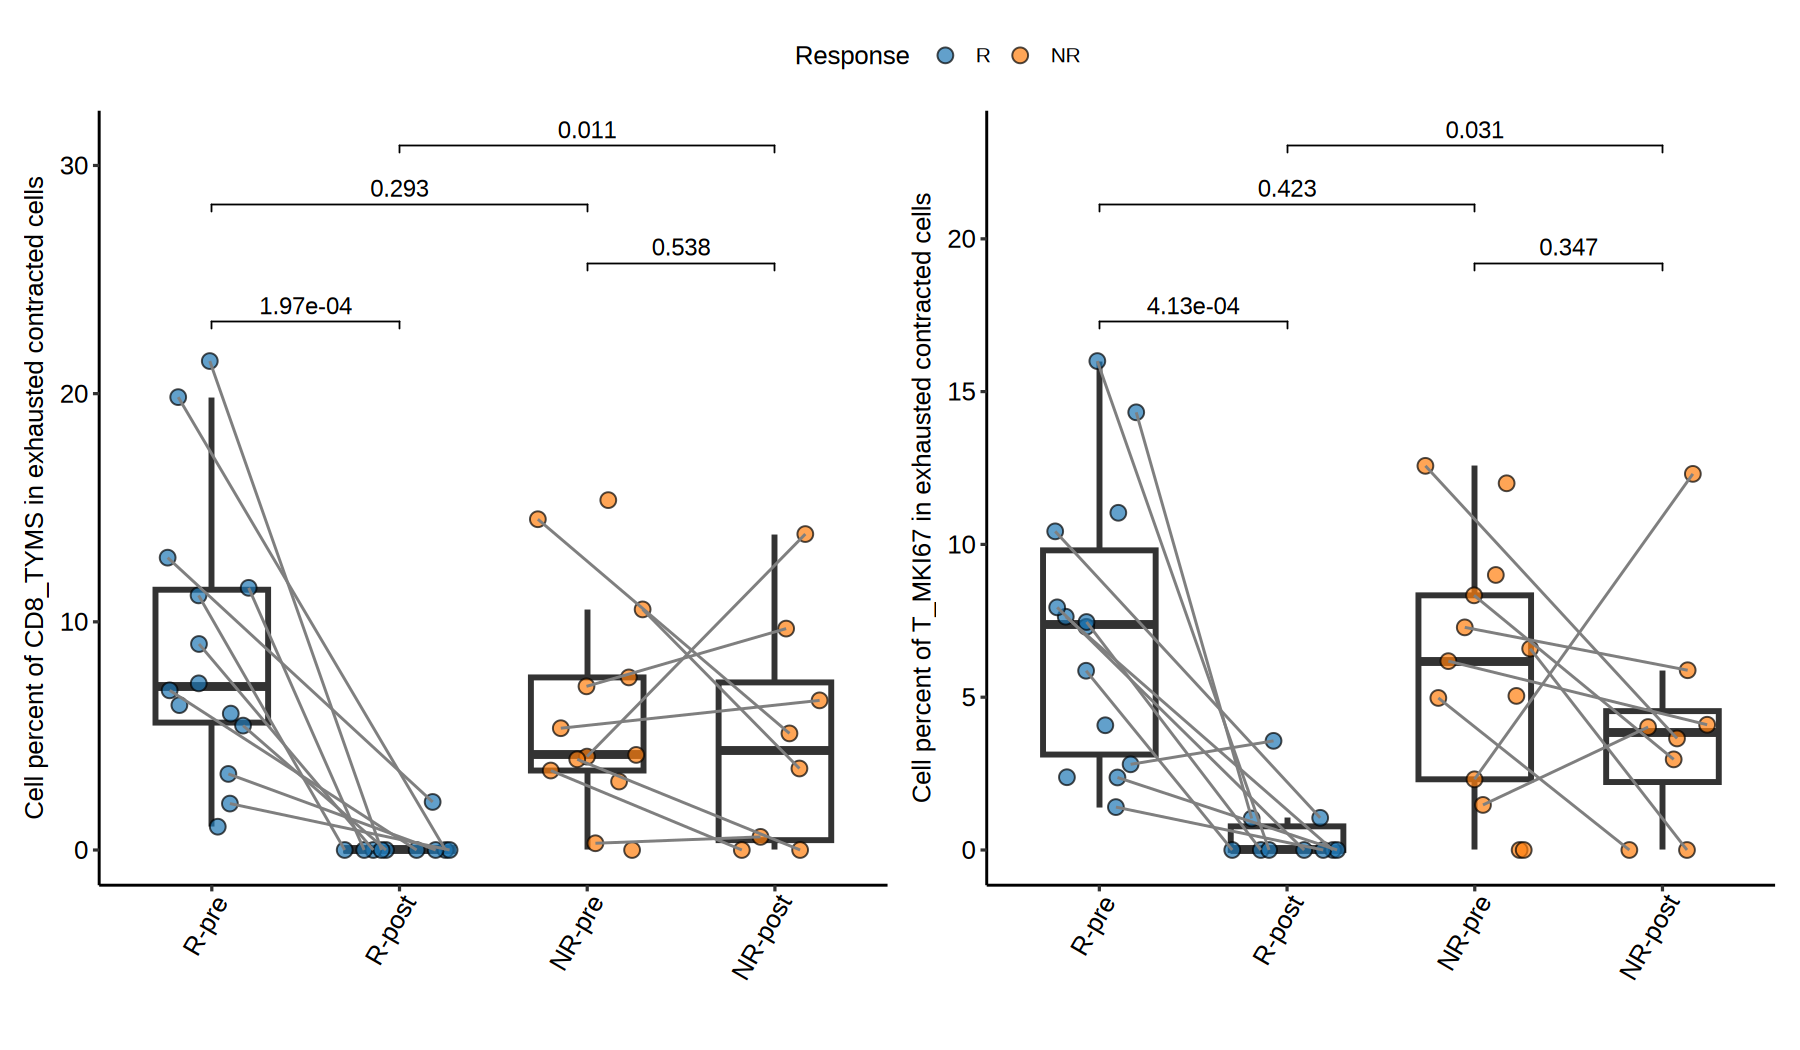

In [57]:

p_ls <- lapply(X = used_ctypes, function(ctype) {
    p_i <- df %>%
    filter(n_cell_per_sample >= min_cell) %>%
    filter(cellgp == ctype) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp, facet_by = NULL,
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60)  +
    labs(y = str_glue('Cell percent of {ctype} in exhausted contracted cells'), fill = 'Response') +
    theme(legend.position = 'right')
    p_i <- configure_panel_wilcox(
        p_i,
        x = 'plot_x', y = 'pct', comparisons = gp_comp_map[[gp]],
        use_paired = FALSE, pair_by = 'patient',
        paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
        apply_correction = TRUE, correction_method = 'BH'
    )
    print(get_panel_wilcox_stats(p_i), n = Inf)
    p_i
})
p <- wrap_plots(p_ls, ncol = 2, guides = 'collect') & theme(legend.position = 'top')
ggsave(filename = str_glue('{outdir}/{prefix}-{min_cell}.pdf'), width = 4, height = 5, plot = p)

# 在当前 notebook 中显示组合图。
p


### 4h: exhausted clusters in cytotoxic expanded

In [58]:
prefix <- 'fig4h-cell_pct_in_cyto_expand'
target_ctype <- 'exhausted clusters'
df <- clone_source %>% 
    filter(clone_cat == 'Expanded clones in cytotoxic clusters') %>% 
    mutate(cellgp = case_match(
        celltype,
        cell_state_map$exhausted ~ 'exhausted clusters',
        cell_state_map$dying ~ 'T_Mito',
        .default = 'others'
    )) %>% 
    count(patient, sample_type, cellgp, name = 'n_cell') %>% 
    pivot_wider(id_cols = c('patient', 'sample_type'), names_from = 'cellgp',
                values_from = 'n_cell', values_fill = 0) %>% 
    pivot_longer(cols = -c('patient', 'sample_type'), names_to = 'cellgp', values_to = 'n_cell') %>% 
    add_count(patient, sample_type, name = 'n_cell_per_sample', wt = n_cell) %>% 
    mutate(pct = 100 * n_cell / n_cell_per_sample) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
    
loginfo('%g records', nrow(df))
df %>% write_tsv(str_glue('{outdir}/{prefix}.tsv'))


2026-07-17 22:49:16.906584 INFO::174 records


# A tibble: 2 × 13
  group1 group2  comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>              <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  NR-pre                 1 FALSE     15    11      NA          44 0.0485 
2 R-post NR-post                2 FALSE     16    13      NA          41 0.00482
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


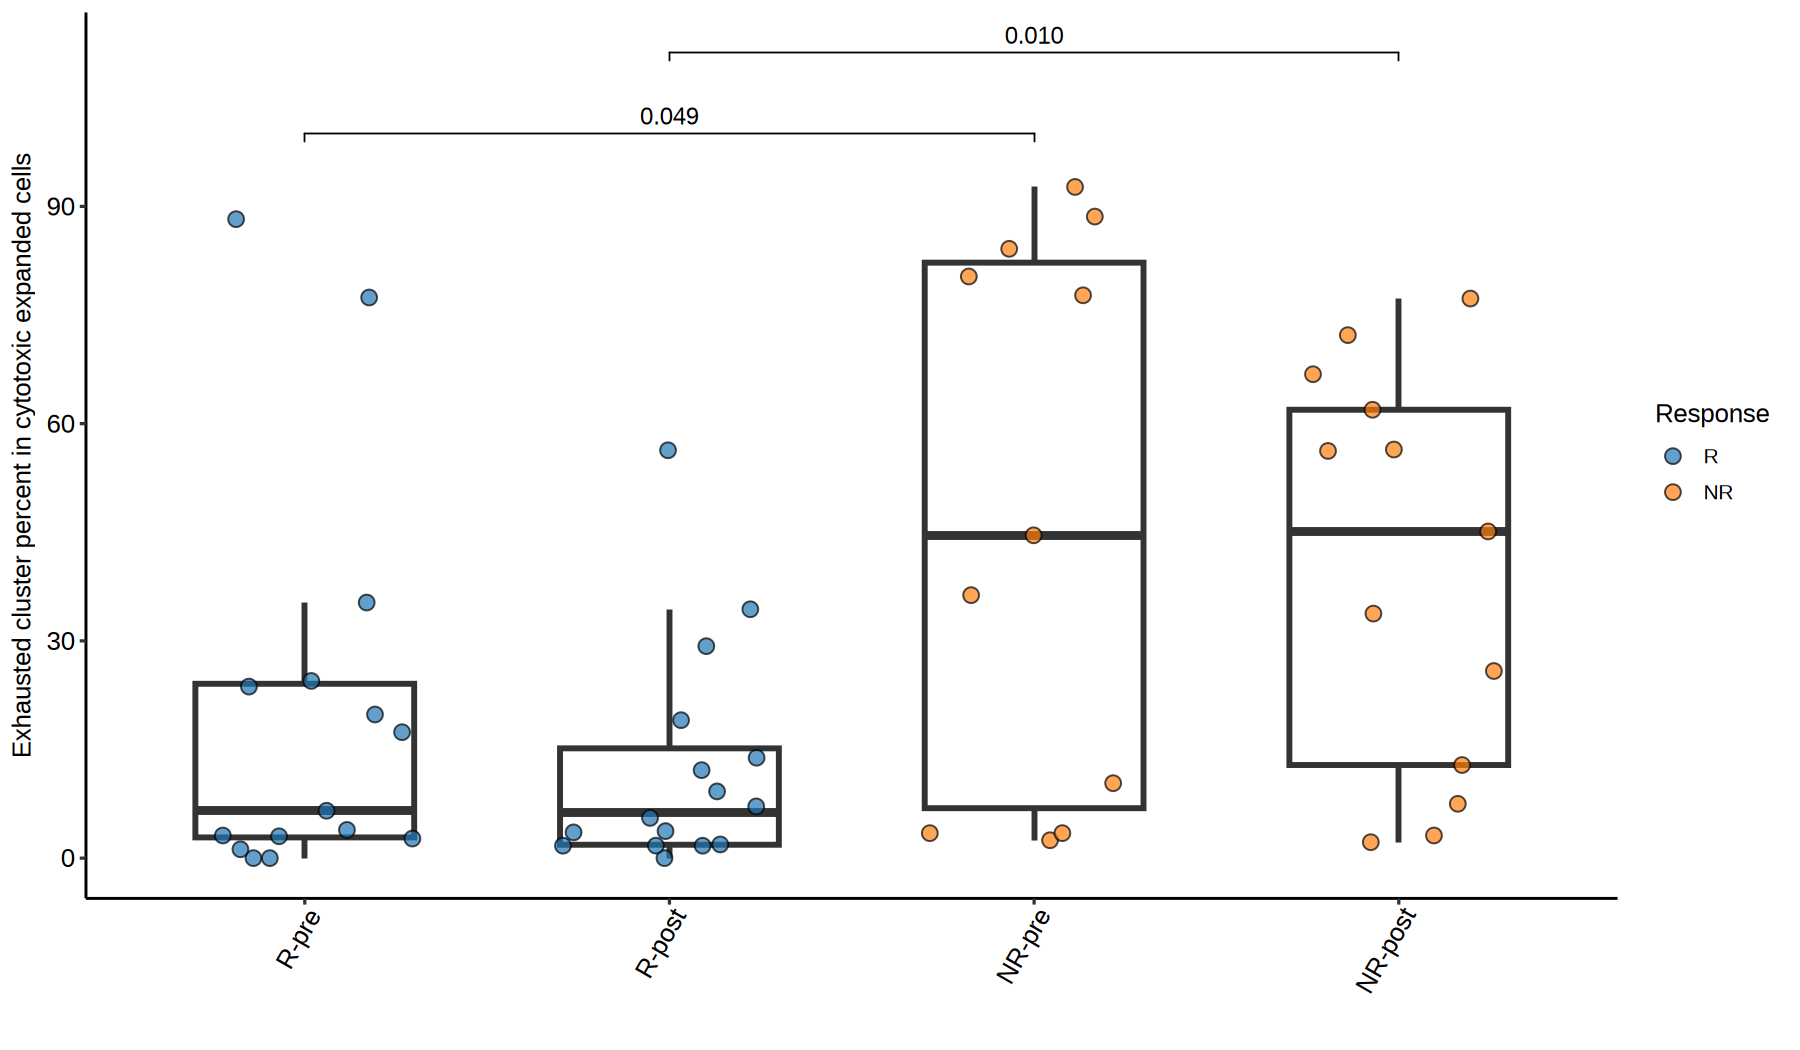

In [59]:
fig4h_comparisons <- list(
    c('R-pre', 'NR-pre'),
    c('R-post', 'NR-post')
)

p <- df %>%
    filter(
        n_cell_per_sample >= min_cell,
        cellgp == target_ctype
    ) %>%
    cell_comp_boxplot(
        x = c(gp, 'sample_type'),
        y = 'pct',
        pt_fill = gp,
        pair_by = NULL,
        facet_by = NULL,
        xorder = comb_order,
        fill_order = gp_lvls[[gp]],
        xangle = 60
    ) +
    labs(
        y = 'Exhausted cluster percent in cytotoxic expanded cells',
        fill = 'Response'
    ) +
    theme(legend.position = 'right')

p <- configure_panel_wilcox(
    p,
    x = 'plot_x',
    y = 'pct',
    comparisons = fig4h_comparisons,
    use_paired = FALSE,
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue('{outdir}/{prefix}-{min_cell}.pdf'),
    width = 4,
    height = 5,
    plot = p
)

# 在当前 notebook 中显示最后生成的图。
p


## Export the final core resource data